In [1]:
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
import lightgbm as lgb

import os
import sys
root_path="/home/iaw/DATA2/AAReact/src"
sys.path.append(root_path)
from util.RegressMetrics import r2_score, mse_score, mae_score, rmse_score
from util.train_tools import build_model, search_parms, print_metric, eval_dataset_split, draw_pred_result

import seaborn as sns
from matplotlib import pyplot as plt

from typing import List, Tuple
from rich.table import Table
from rich import print as rp
from rich.progress import track
import shap
import pickle

In [22]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
m = Chem.MolFromSmiles('O=C(NCc1cc(OC)c(O)cc1)Cc1cocc1CC')
core = MurckoScaffold.GetScaffoldForMol(m)
from rdkit.Chem.rdchem import Mol
from typing import Dict, List, Any

In [24]:
A: Dict[Mol, List[int]] = {core: [0]}

In [25]:
A

{<rdkit.Chem.rdchem.Mol at 0x7fab10073e60>: [0]}

Text(0, 0.5, 'R2')

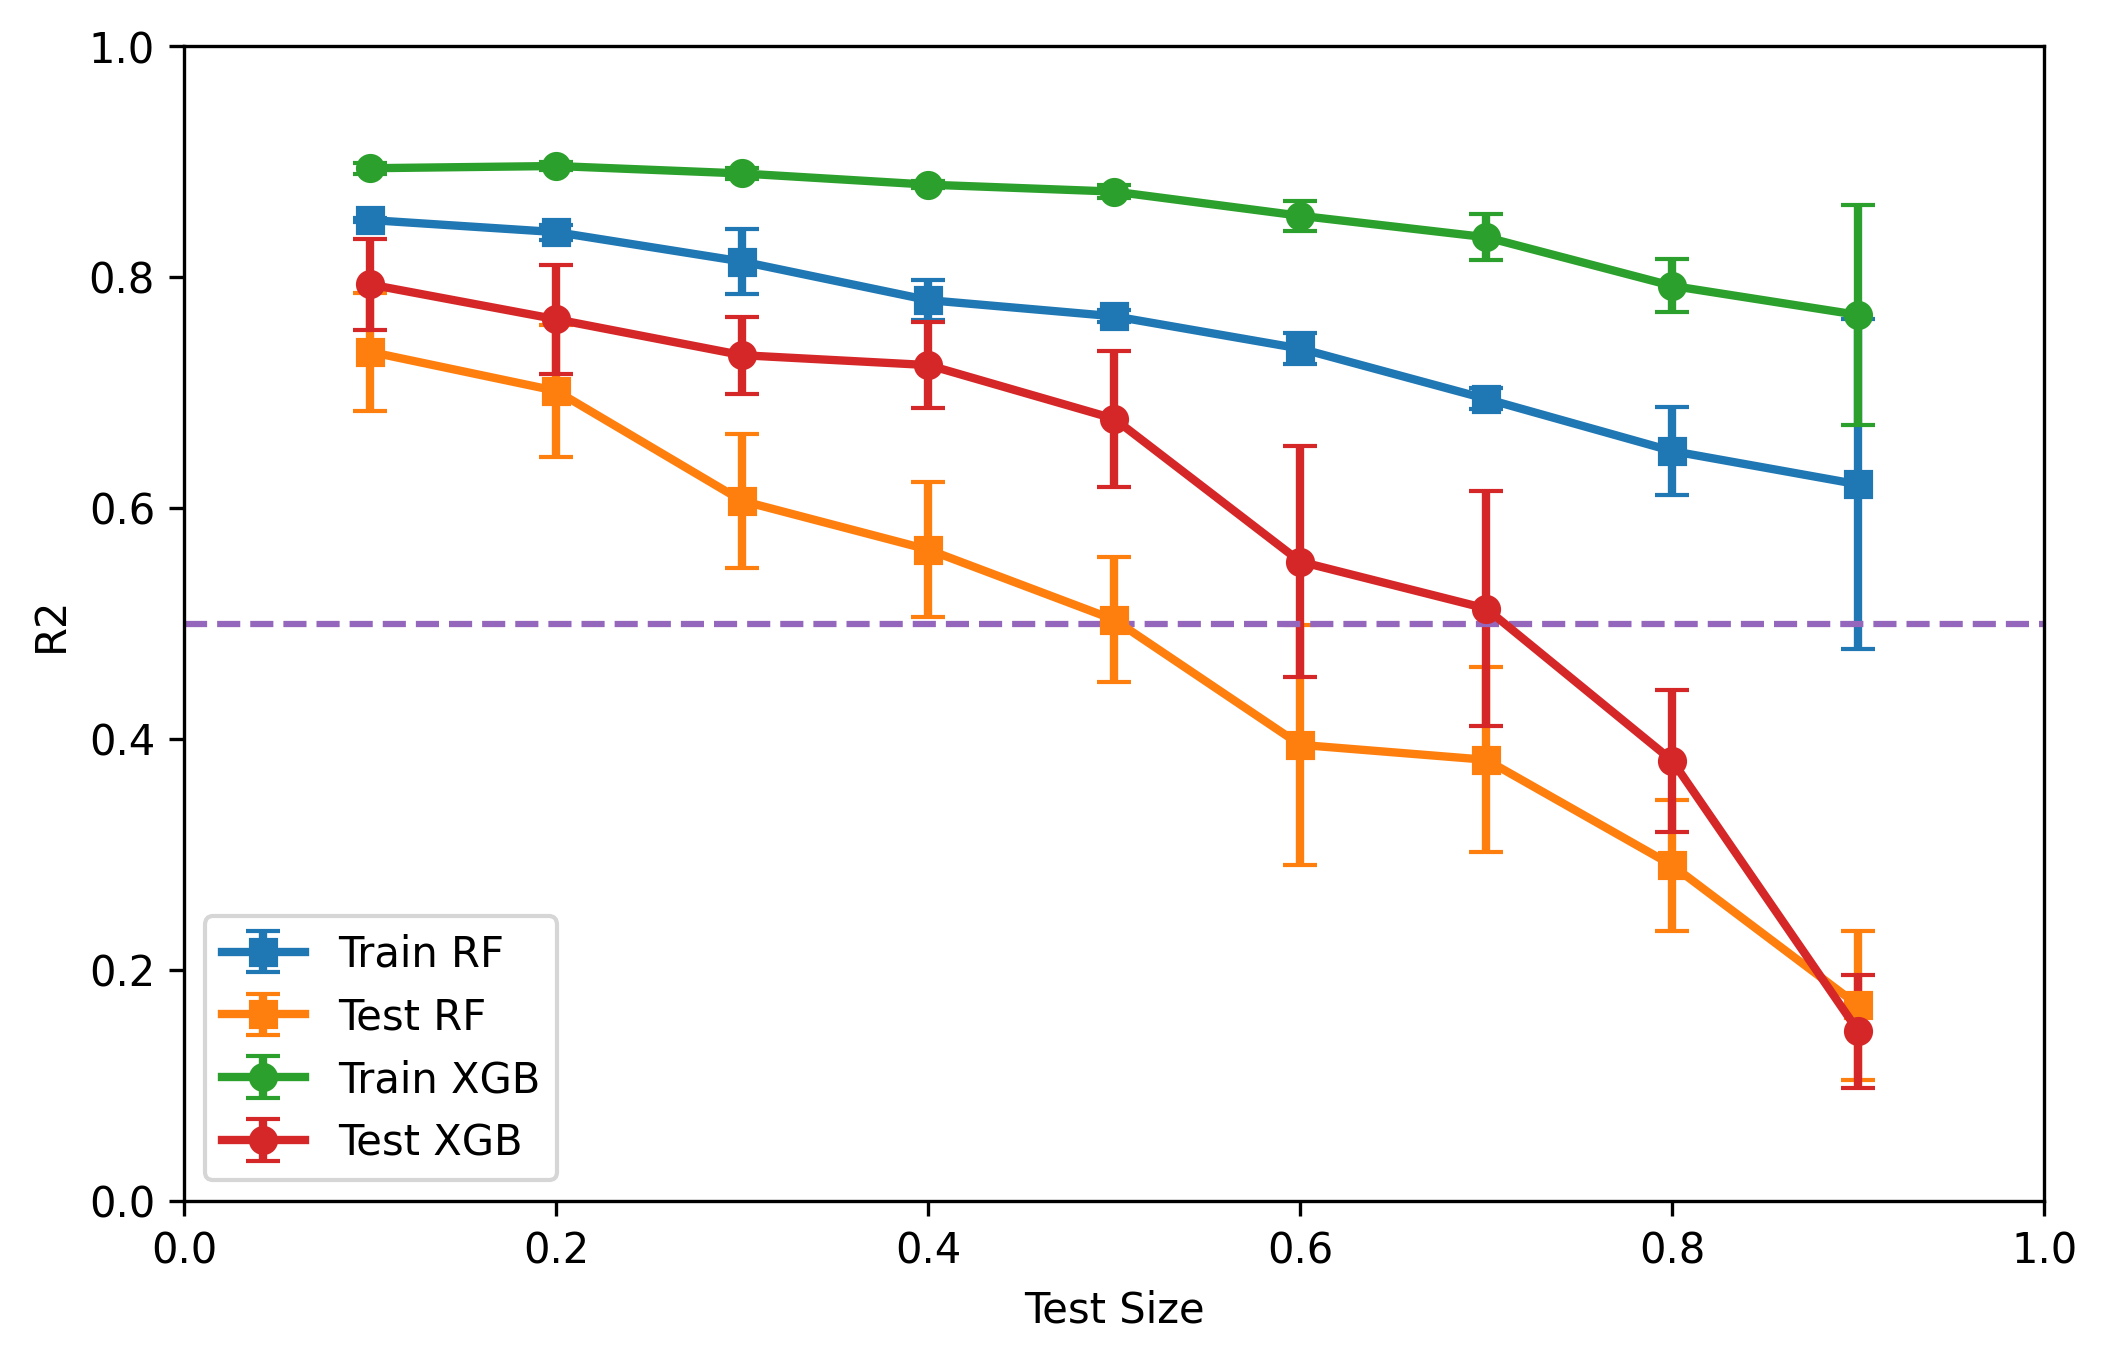

In [12]:

# 加载rdkit desc 3数据
prefix = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_416/4_gen_feature/rdkit_3"
data_x = np.load("{}_data_x.npy".format(prefix))
data_y = np.load("{}_data_y.npy".format(prefix))
with open("{}_x_label.pkl".format(prefix), "rb") as f:
    x_label = pickle.load(f)
with open("{}_data_class.pkl".format(prefix), "rb") as f:
    data_class = pickle.load(f)

# 超参之后的参数
rf_best_params = {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 140}
# xgb第一次超参
#xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 150, 'subsample': 0.8}
# xgb第二次超参
xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 20, 'min_child_weight': 5, 'n_estimators': 30, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.9}

# 评估模型对不同数据集划分的敏感性
rf_eval_dataset_split_result = eval_dataset_split(seed_s = [1, 2, 3, 4], test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                   , parms = rf_best_params
                   , model_name = "rf"
                   , data_x = data_x, data_y = data_y, data_class = data_class
                   , eval_func = r2_score) 
xgb_eval_dataset_split_result = eval_dataset_split(seed_s = [1, 2, 3, 4], test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                   , parms = xgb_best_params
                   , model_name = "xgb"
                   , data_x = data_x, data_y = data_y, data_class = data_class
                   , eval_func = r2_score) 

# 绘制模型对不同数据集划分的敏感性
test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
plt.figure(figsize=(8, 5), dpi=300)
plt.errorbar(test_size_s, rf_eval_dataset_split_result[0], yerr=rf_eval_dataset_split_result[1]
             , label = "Train RF" , fmt="-s", capsize=4,linewidth=2, markersize=6)
plt.errorbar(test_size_s, rf_eval_dataset_split_result[2], yerr=rf_eval_dataset_split_result[3]
             , label = "Test RF" , fmt="-s", capsize=4,linewidth=2, markersize=6)

plt.errorbar(test_size_s, xgb_eval_dataset_split_result[0], yerr=xgb_eval_dataset_split_result[1]
             , label = "Train XGB" , fmt="-o", capsize=4,linewidth=2, markersize=6)
plt.errorbar(test_size_s, xgb_eval_dataset_split_result[2], yerr=xgb_eval_dataset_split_result[3]
             , label = "Test XGB" , fmt="-o", capsize=4,linewidth=2, markersize=6)

plt.plot([0, 1], [0.5, 0.5], linestyle='--')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("Test Size")
plt.ylabel("R2")

In [ ]:

# 加载soap 3数据
prefix = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_416/4_gen_feature/soap_3"
data_x = np.load("{}_data_x.npy".format(prefix))
data_y = np.load("{}_data_y.npy".format(prefix))
with open("{}_x_label.pkl".format(prefix), "rb") as f:
    x_label = pickle.load(f)
with open("{}_data_class.pkl".format(prefix), "rb") as f:
    data_class = pickle.load(f)

# 超参之后的参数
rf_best_params = {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 120}
xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 51, 'subsample': 1.0}

# 评估模型对不同数据集划分的敏感性
rf_eval_dataset_split_result = eval_dataset_split(seed_s = [1, 2, 3, 4], test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                   , parms = rf_best_params
                   , model_name = "rf"
                   , data_x = data_x, data_y = data_y, data_class = data_class
                   , eval_func = r2_score) 
xgb_eval_dataset_split_result = eval_dataset_split(seed_s = [1, 2, 3, 4], test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                   , parms = xgb_best_params
                   , model_name = "xgb"
                   , data_x = data_x, data_y = data_y, data_class = data_class
                   , eval_func = r2_score) 

# 绘制模型对不同数据集划分的敏感性
test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
plt.figure(figsize=(8, 5), dpi=300)
plt.errorbar(test_size_s, rf_eval_dataset_split_result[0], yerr=rf_eval_dataset_split_result[1]
             , label = "Train RF" , fmt="-s", capsize=4,linewidth=2, markersize=6)
plt.errorbar(test_size_s, rf_eval_dataset_split_result[2], yerr=rf_eval_dataset_split_result[3]
             , label = "Test RF" , fmt="-s", capsize=4,linewidth=2, markersize=6)

plt.errorbar(test_size_s, xgb_eval_dataset_split_result[0], yerr=xgb_eval_dataset_split_result[1]
             , label = "Train XGB" , fmt="-o", capsize=4,linewidth=2, markersize=6)
plt.errorbar(test_size_s, xgb_eval_dataset_split_result[2], yerr=xgb_eval_dataset_split_result[3]
             , label = "Test XGB" , fmt="-o", capsize=4,linewidth=2, markersize=6)

plt.plot([0, 1], [0.5, 0.5], linestyle='--')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("Test Size")
plt.ylabel("R2")

In [ ]:

# 加载acsf 3数据
prefix = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_416/4_gen_feature/acsf_3"
data_x = np.load("{}_data_x.npy".format(prefix))
data_y = np.load("{}_data_y.npy".format(prefix))
with open("{}_x_label.pkl".format(prefix), "rb") as f:
    x_label = pickle.load(f)
with open("{}_data_class.pkl".format(prefix), "rb") as f:
    data_class = pickle.load(f)

# 超参之后的参数
rf_best_params = {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 120}
xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 51, 'subsample': 1.0}

# 评估模型对不同数据集划分的敏感性
rf_eval_dataset_split_result = eval_dataset_split(seed_s = [1, 2, 3, 4], test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                   , parms = rf_best_params
                   , model_name = "rf"
                   , data_x = data_x, data_y = data_y, data_class = data_class
                   , eval_func = r2_score) 
xgb_eval_dataset_split_result = eval_dataset_split(seed_s = [1, 2, 3, 4], test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                   , parms = xgb_best_params
                   , model_name = "xgb"
                   , data_x = data_x, data_y = data_y, data_class = data_class
                   , eval_func = r2_score) 

# 绘制模型对不同数据集划分的敏感性
test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
plt.figure(figsize=(8, 5), dpi=300)
plt.errorbar(test_size_s, rf_eval_dataset_split_result[0], yerr=rf_eval_dataset_split_result[1]
             , label = "Train RF" , fmt="-s", capsize=4,linewidth=2, markersize=6)
plt.errorbar(test_size_s, rf_eval_dataset_split_result[2], yerr=rf_eval_dataset_split_result[3]
             , label = "Test RF" , fmt="-s", capsize=4,linewidth=2, markersize=6)

plt.errorbar(test_size_s, xgb_eval_dataset_split_result[0], yerr=xgb_eval_dataset_split_result[1]
             , label = "Train XGB" , fmt="-o", capsize=4,linewidth=2, markersize=6)
plt.errorbar(test_size_s, xgb_eval_dataset_split_result[2], yerr=xgb_eval_dataset_split_result[3]
             , label = "Test XGB" , fmt="-o", capsize=4,linewidth=2, markersize=6)

plt.plot([0, 1], [0.5, 0.5], linestyle='--')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("Test Size")
plt.ylabel("R2")

Text(0, 0.5, 'R2')

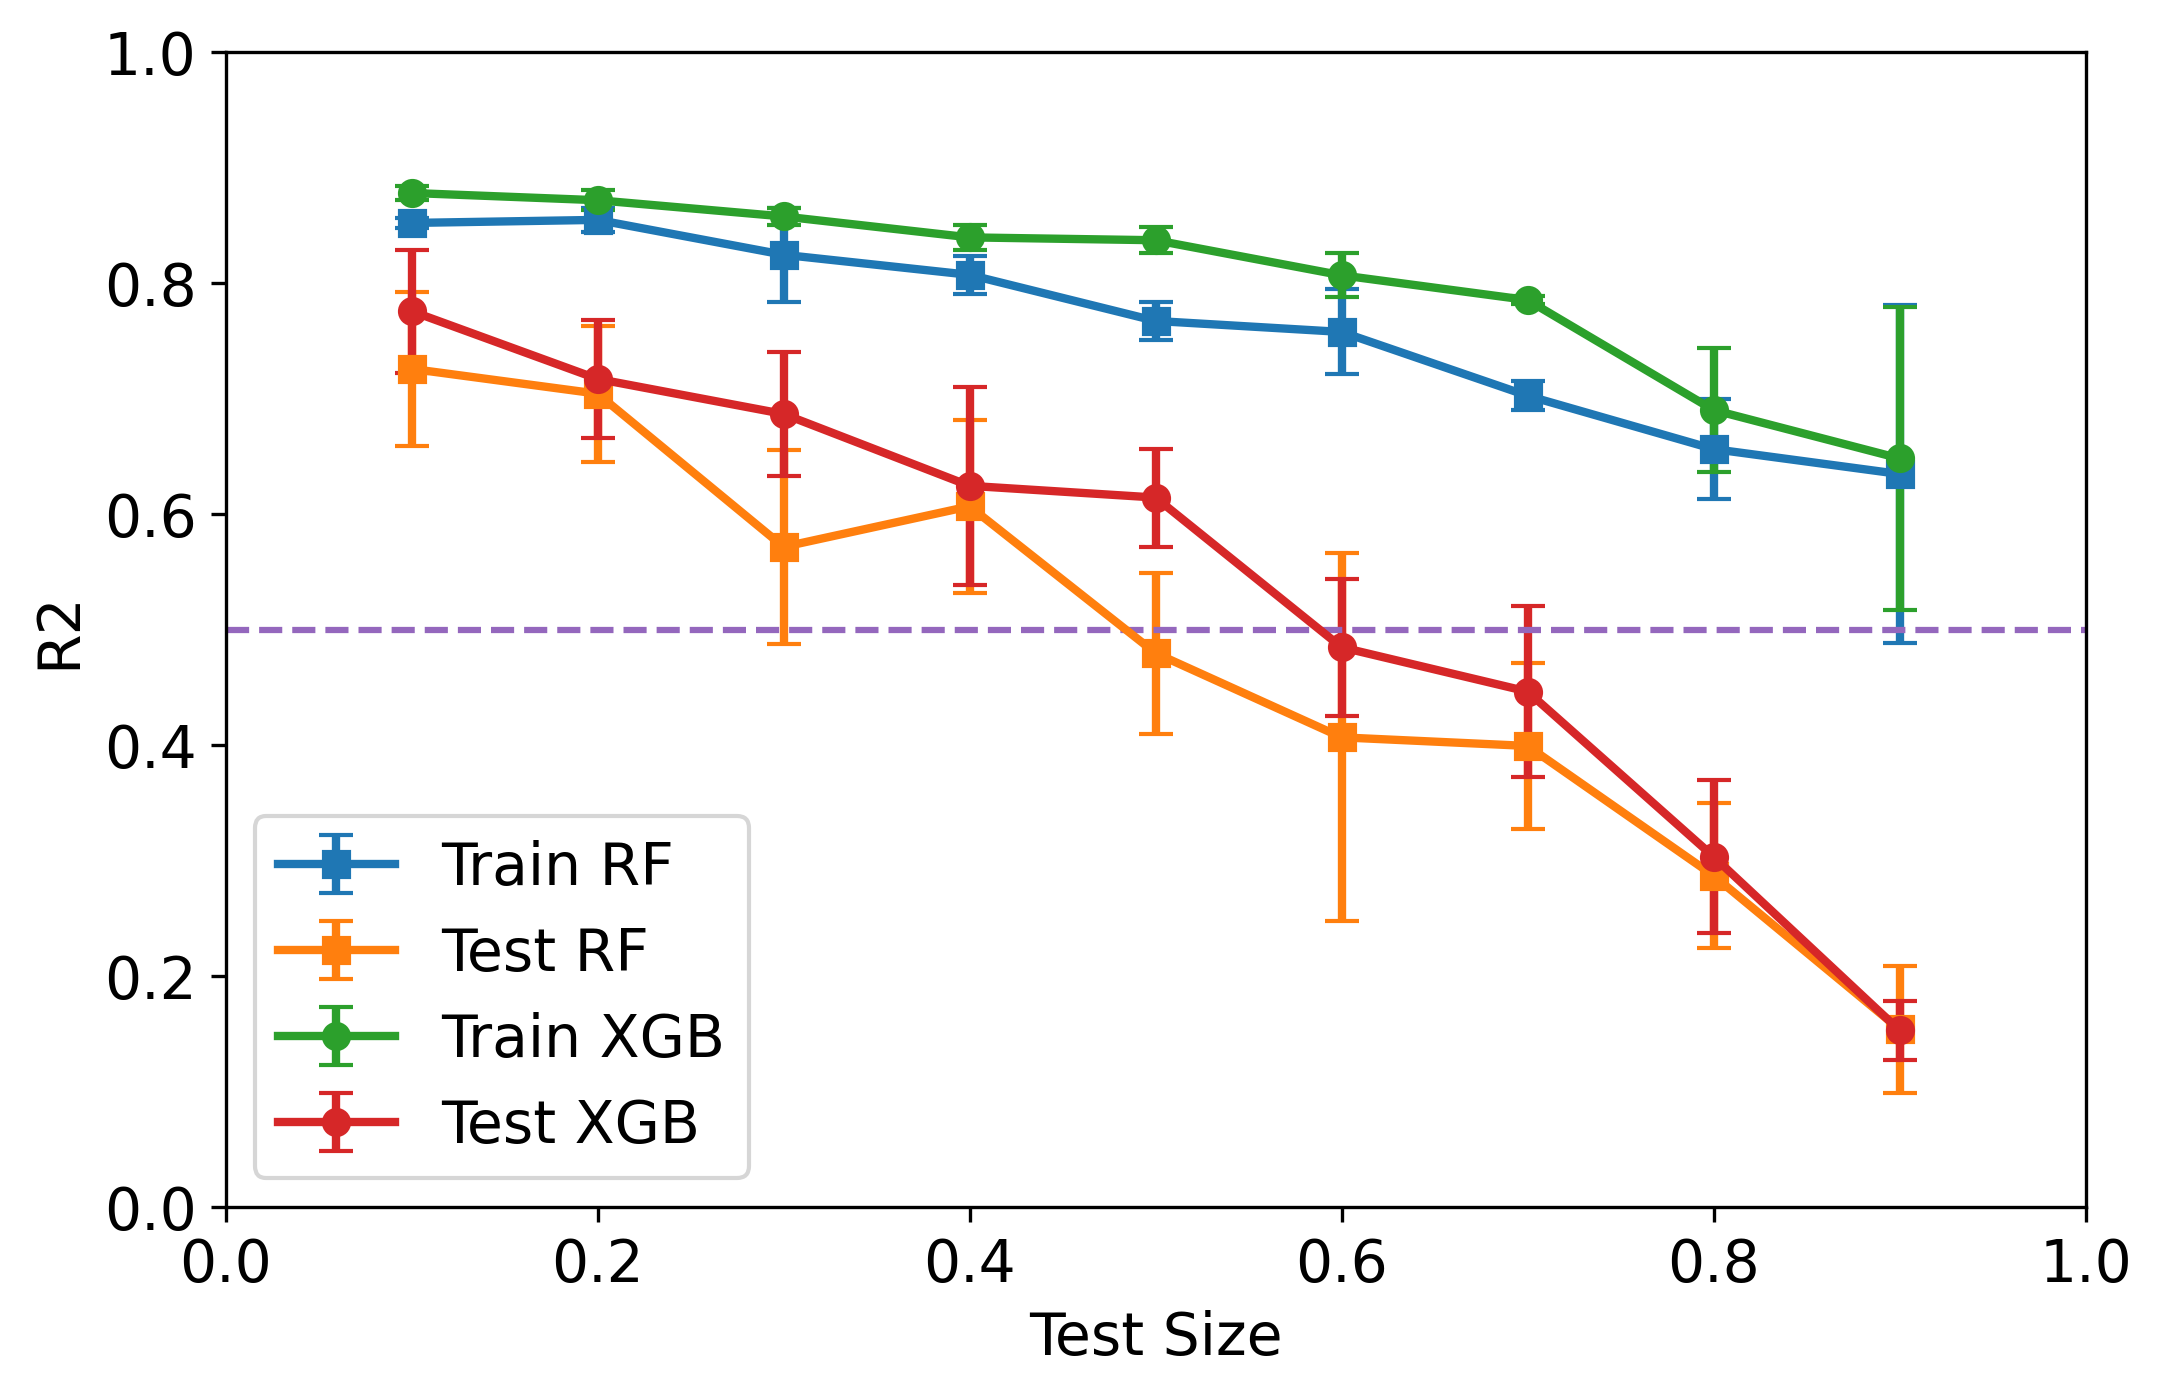

In [31]:
# 加载rdkit_soap 3数据
prefix = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_416/4_gen_feature/rdkit_soap_3"
data_x = np.load("{}_data_x.npy".format(prefix))
data_y = np.load("{}_data_y.npy".format(prefix))
with open("{}_x_label.pkl".format(prefix), "rb") as f:
    x_label = pickle.load(f)
with open("{}_data_class.pkl".format(prefix), "rb") as f:
    data_class = pickle.load(f)

# 超参之后的参数
rf_best_params = {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 20}
xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 50, 'reg_alpha': 0.8, 'reg_lambda': 0.8, 'subsample': 0.5}

# 评估模型对不同数据集划分的敏感性
rf_eval_dataset_split_result = eval_dataset_split(seed_s = [1, 2, 3, 4], test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                   , parms = rf_best_params
                   , model_name = "rf"
                   , data_x = data_x, data_y = data_y, data_class = data_class
                   , eval_func = r2_score) 
xgb_eval_dataset_split_result = eval_dataset_split(seed_s = [1, 2, 3, 4], test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
                   , parms = xgb_best_params
                   , model_name = "xgb"
                   , data_x = data_x, data_y = data_y, data_class = data_class
                   , eval_func = r2_score) 

# 绘制模型对不同数据集划分的敏感性
test_size_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
plt.figure(figsize=(8, 5), dpi=300)
plt.errorbar(test_size_s, rf_eval_dataset_split_result[0], yerr=rf_eval_dataset_split_result[1]
             , label = "Train RF" , fmt="-s", capsize=4,linewidth=2, markersize=6)
plt.errorbar(test_size_s, rf_eval_dataset_split_result[2], yerr=rf_eval_dataset_split_result[3]
             , label = "Test RF" , fmt="-s", capsize=4,linewidth=2, markersize=6)

plt.errorbar(test_size_s, xgb_eval_dataset_split_result[0], yerr=xgb_eval_dataset_split_result[1]
             , label = "Train XGB" , fmt="-o", capsize=4,linewidth=2, markersize=6)
plt.errorbar(test_size_s, xgb_eval_dataset_split_result[2], yerr=xgb_eval_dataset_split_result[3]
             , label = "Test XGB" , fmt="-o", capsize=4,linewidth=2, markersize=6)

plt.plot([0, 1], [0.5, 0.5], linestyle='--')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("Test Size")
plt.ylabel("R2")

# 模型保存
1. 随机数: `1`
2. test_size: `0.2`
3. 描述符: `rdkit+soap`
4. 模型类型: `xgb`
5. 模型保存: `xgb_model_seed_1_split_0-2_hyper2_rdkit_soap.pkl`

In [27]:
seed = 1
test_size = 0.2
prefix = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_416/4_gen_feature/rdkit_soap_3"
data_x = np.load("{}_data_x.npy".format(prefix))
data_y = np.load("{}_data_y.npy".format(prefix))
with open("{}_x_label.pkl".format(prefix), "rb") as f:
    x_label = pickle.load(f)
with open("{}_data_class.pkl".format(prefix), "rb") as f:
    data_class = pickle.load(f)

# 超参之后的参数
xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 30, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.9}
X_train, X_test, y_train, y_test,  class_train, class_test = train_test_split(
    data_x,        
    data_y,
    data_class,
    test_size=test_size,
    random_state=seed, 
)
model = build_model("xgb", seed)
model.set_params(**xgb_best_params)
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

from joblib import dump, load
# 需保存模型
dump(model, "xgb_model_seed_1_split_0-2_hyper2_rdkit_soap.pkl")


['xgb_model_seed_1_split_0-2_hyper2_rdkit_soap.pkl']

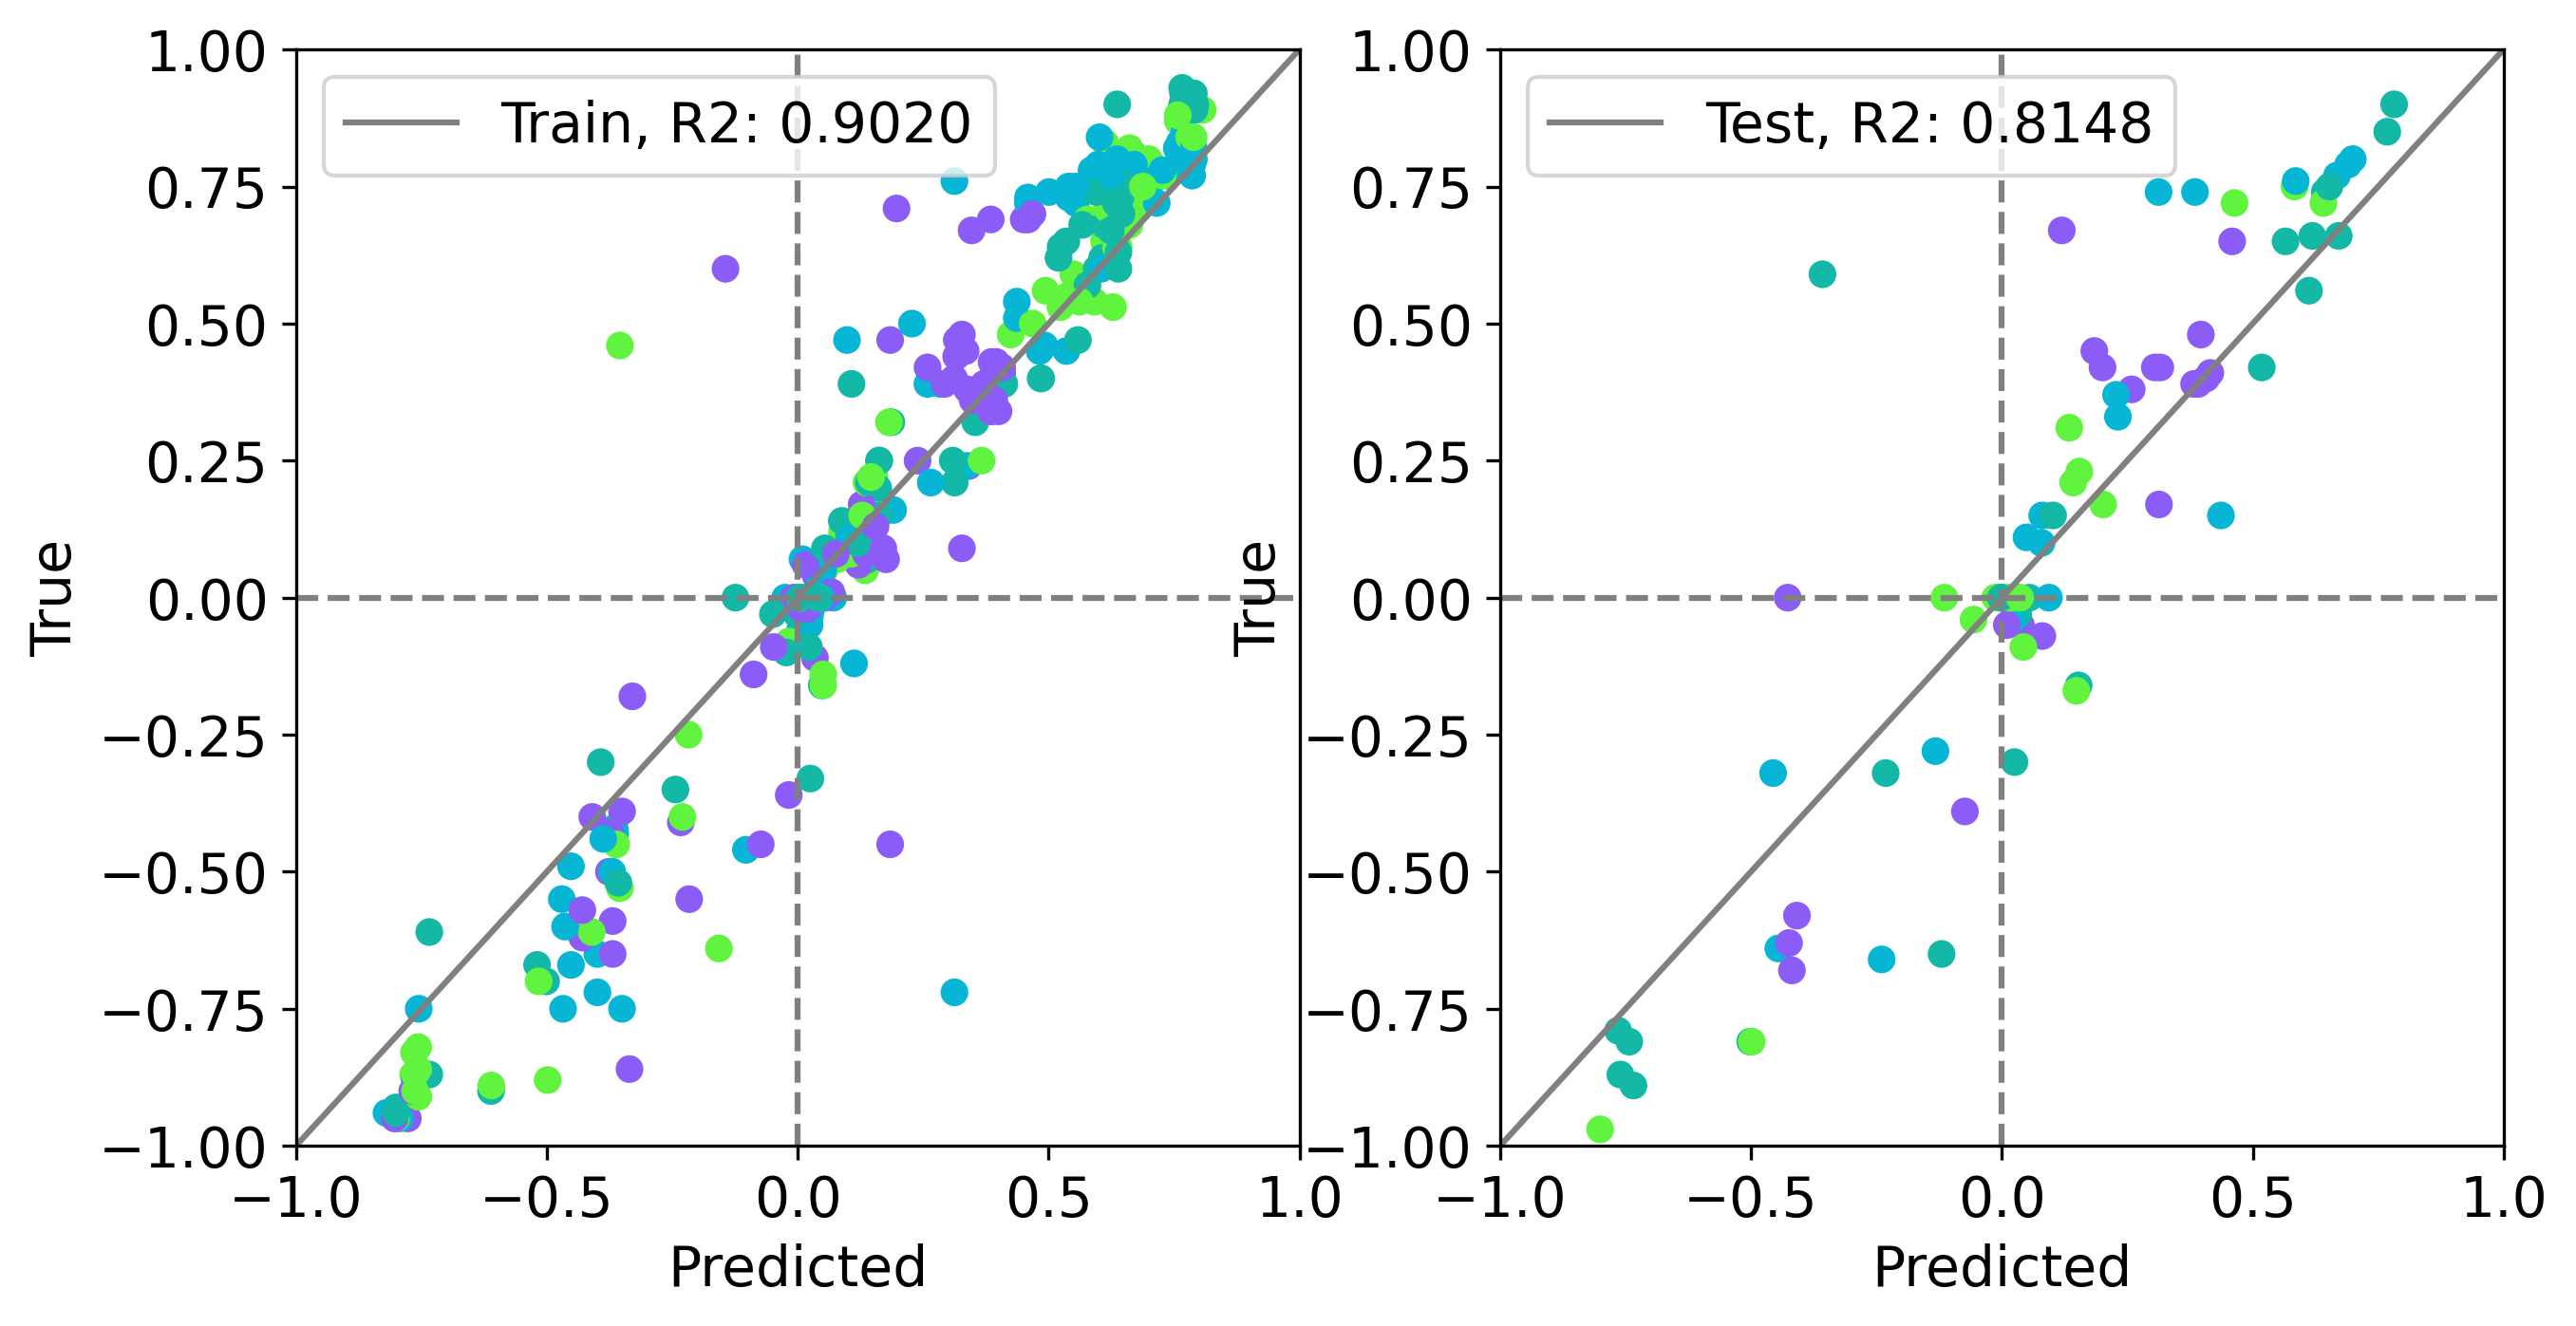

In [28]:
draw_pred_result(y_true_s = (y_train, y_test), y_pred_s = (train_pred, test_pred), r2_s = (r2_score(train_pred, y_train), r2_score(test_pred, y_test)), class_s = (class_train, class_test))

# 模型保存
1. 随机数: `1`
2. test_size: `0.2`
3. 描述符: `rdkit`
4. 模型类型: `xgb`
5. 模型保存: `xgb_model_seed_1_split_0-2_hyper2_rdkit.pkl`

In [ ]:
seed = 1
test_size = 0.2
prefix = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_416/4_gen_feature/rdkit_3"
data_x = np.load("{}_data_x.npy".format(prefix))
data_y = np.load("{}_data_y.npy".format(prefix))
with open("{}_x_label.pkl".format(prefix), "rb") as f:
    x_label = pickle.load(f)
with open("{}_data_class.pkl".format(prefix), "rb") as f:
    data_class = pickle.load(f)
# 超参之后的参数
xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 20, 'min_child_weight': 5, 'n_estimators': 30, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.9}
X_train, X_test, y_train, y_test,  class_train, class_test = train_test_split(
    data_x,        
    data_y,
    data_class,
    test_size=test_size,
    random_state=seed, 
)
model = build_model("xgb", seed)
model.set_params(**xgb_best_params)
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

from joblib import dump, load
# 需保存模型
dump(model, "xgb_model_seed_1_split_0-2_hyper2_rdkit.pkl")


['xgb_model_seed_1_split_0-2_hyper2.pkl']

# 计算一下

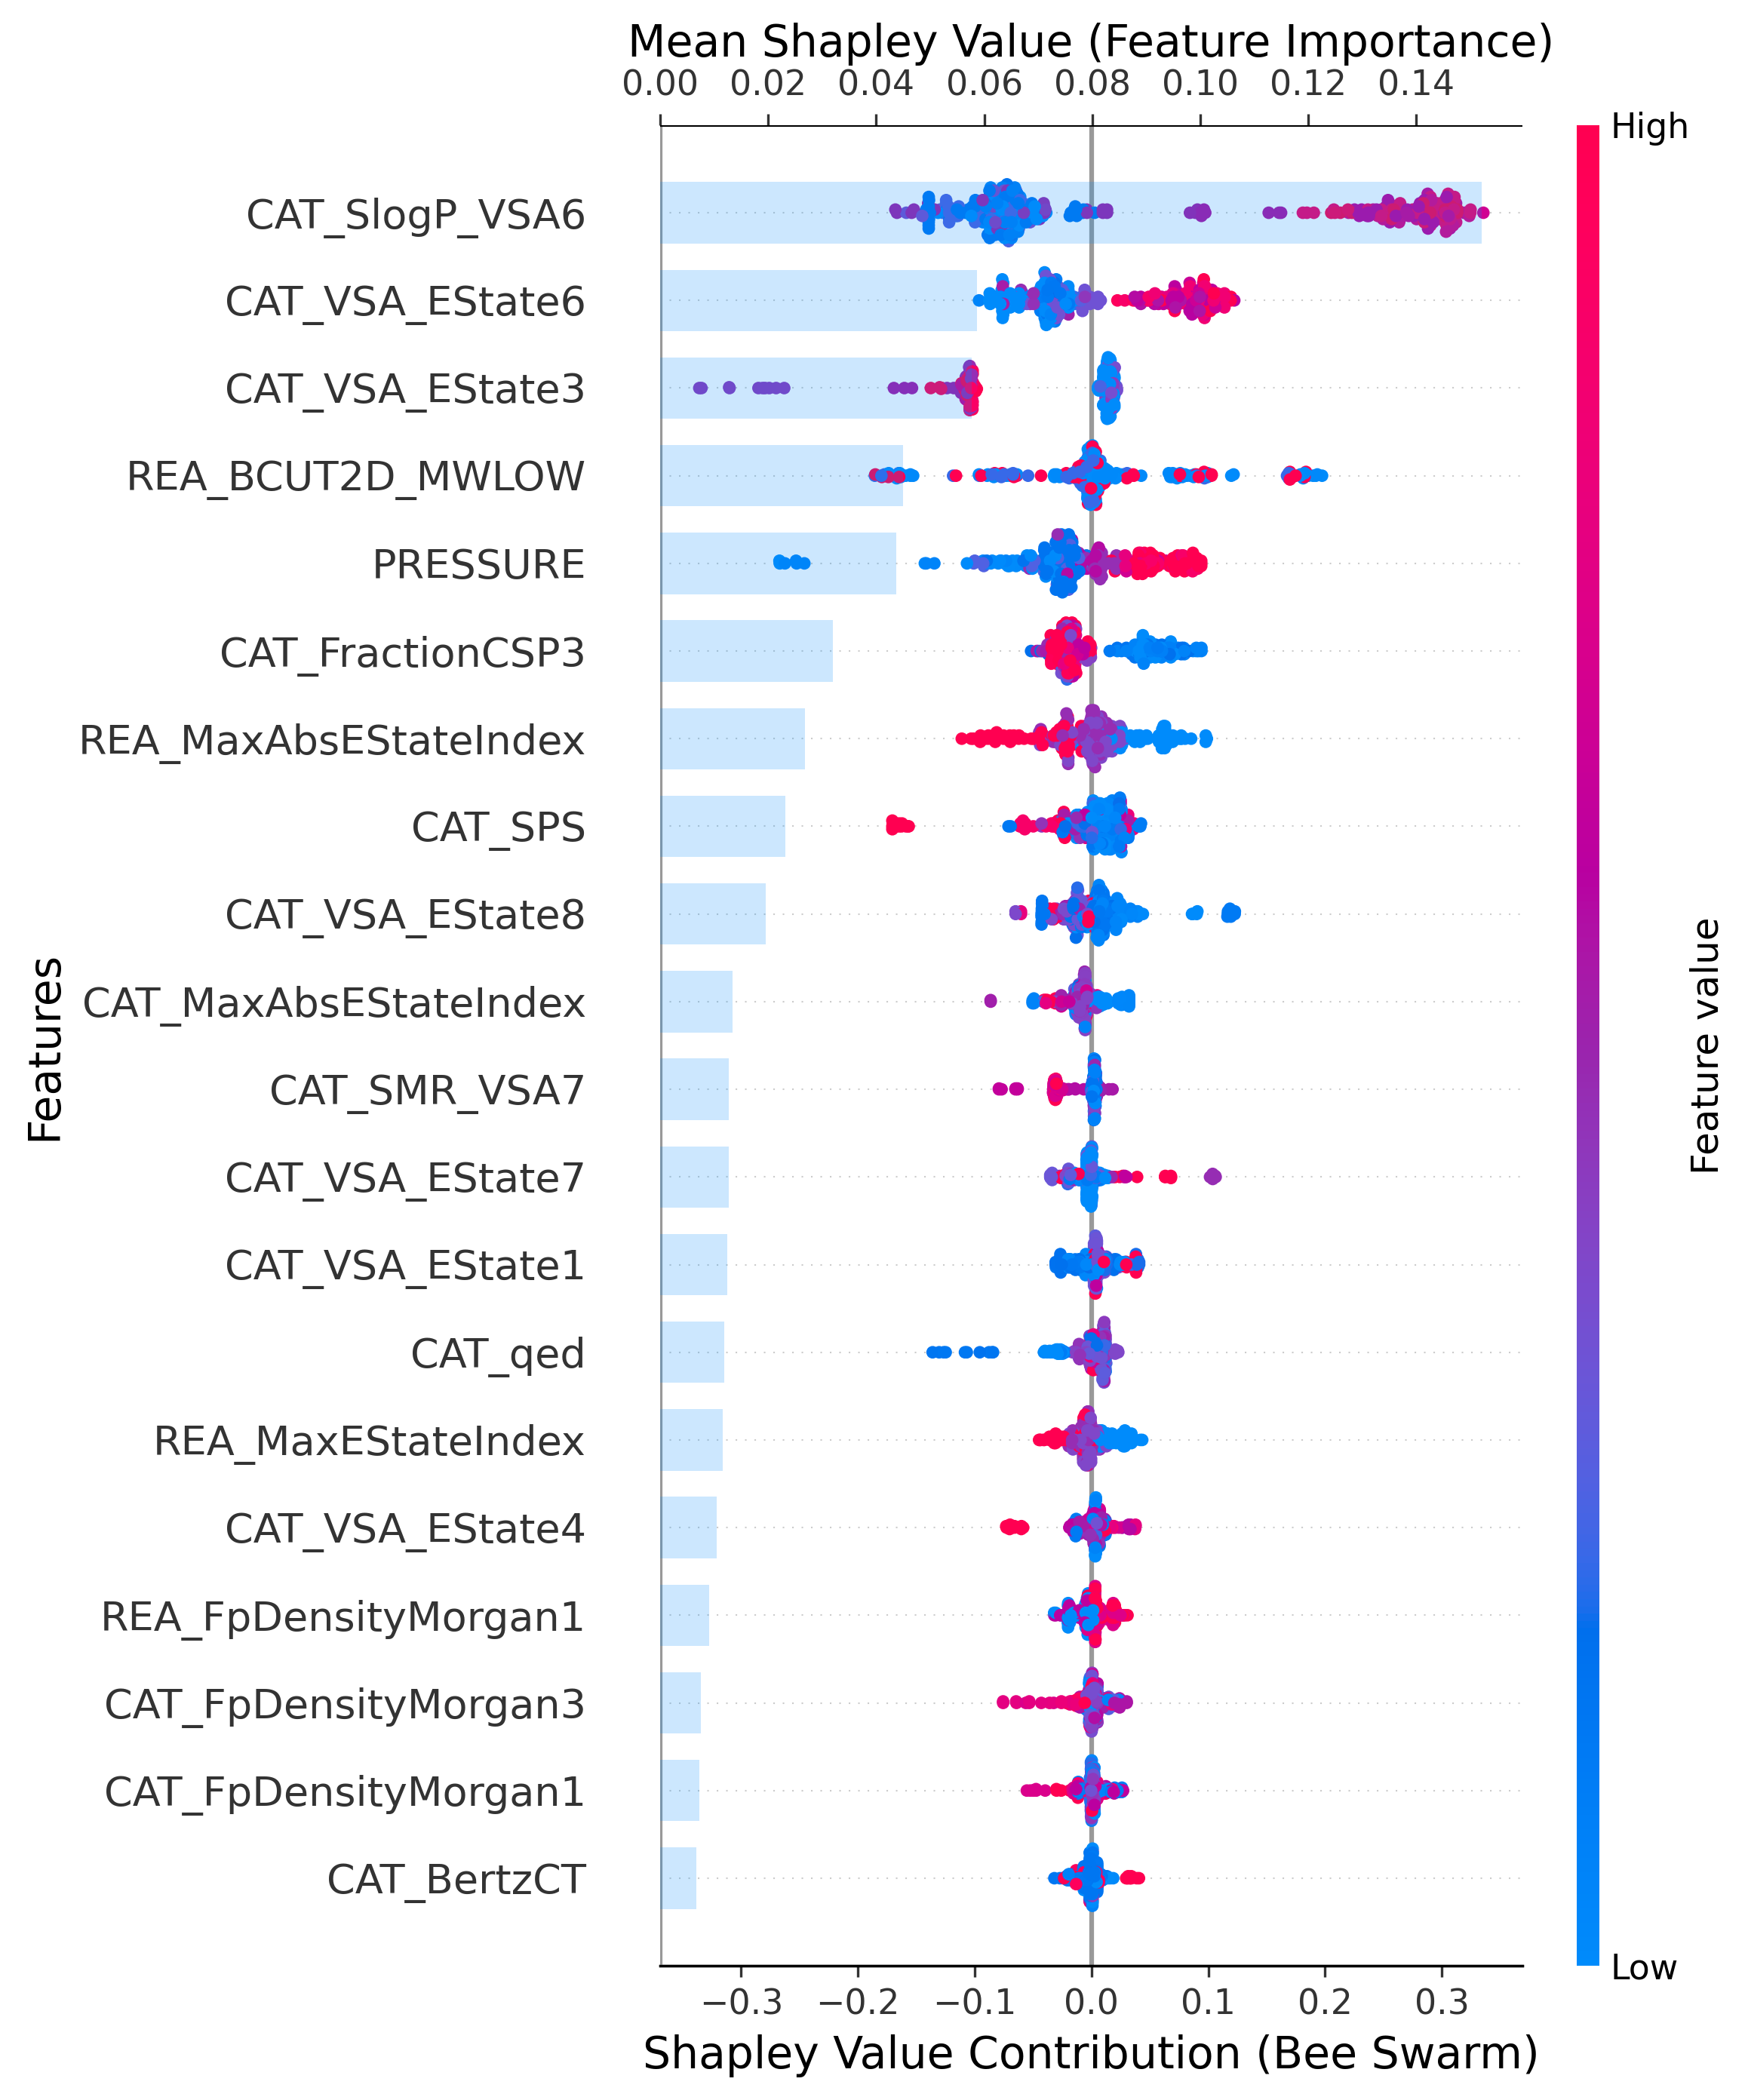

In [14]:
xgb_explainer = shap.TreeExplainer(model)
train_shap_values = xgb_explainer.shap_values(X_train)

labels = x_label
fig, ax1 = plt.subplots(figsize=(10, 8), dpi=300)

plt.rcParams['font.serif'] = 'Times new Roman'
plt.rcParams['font.size'] = 14
shap.summary_plot(train_shap_values, X_train, feature_names=labels, plot_type="dot", show=False)
ax2 = ax1.twiny()
shap.summary_plot(train_shap_values, X_train, feature_names=labels, plot_type="bar", show=False)
ax2.axhline(y=20, color='black', linestyle='-', linewidth=1)
for bar in ax2.patches:
    bar.set_alpha(0.2) 
ax1.set_xlabel('Shapley Value Contribution (Bee Swarm)', fontsize=14)
ax2.set_xlabel('Mean Shapley Value (Feature Importance)', fontsize=14)

ax2.xaxis.set_label_position('top') 
ax2.xaxis.tick_top()
ax1.set_ylabel('Features', fontsize=14)
plt.tight_layout()      


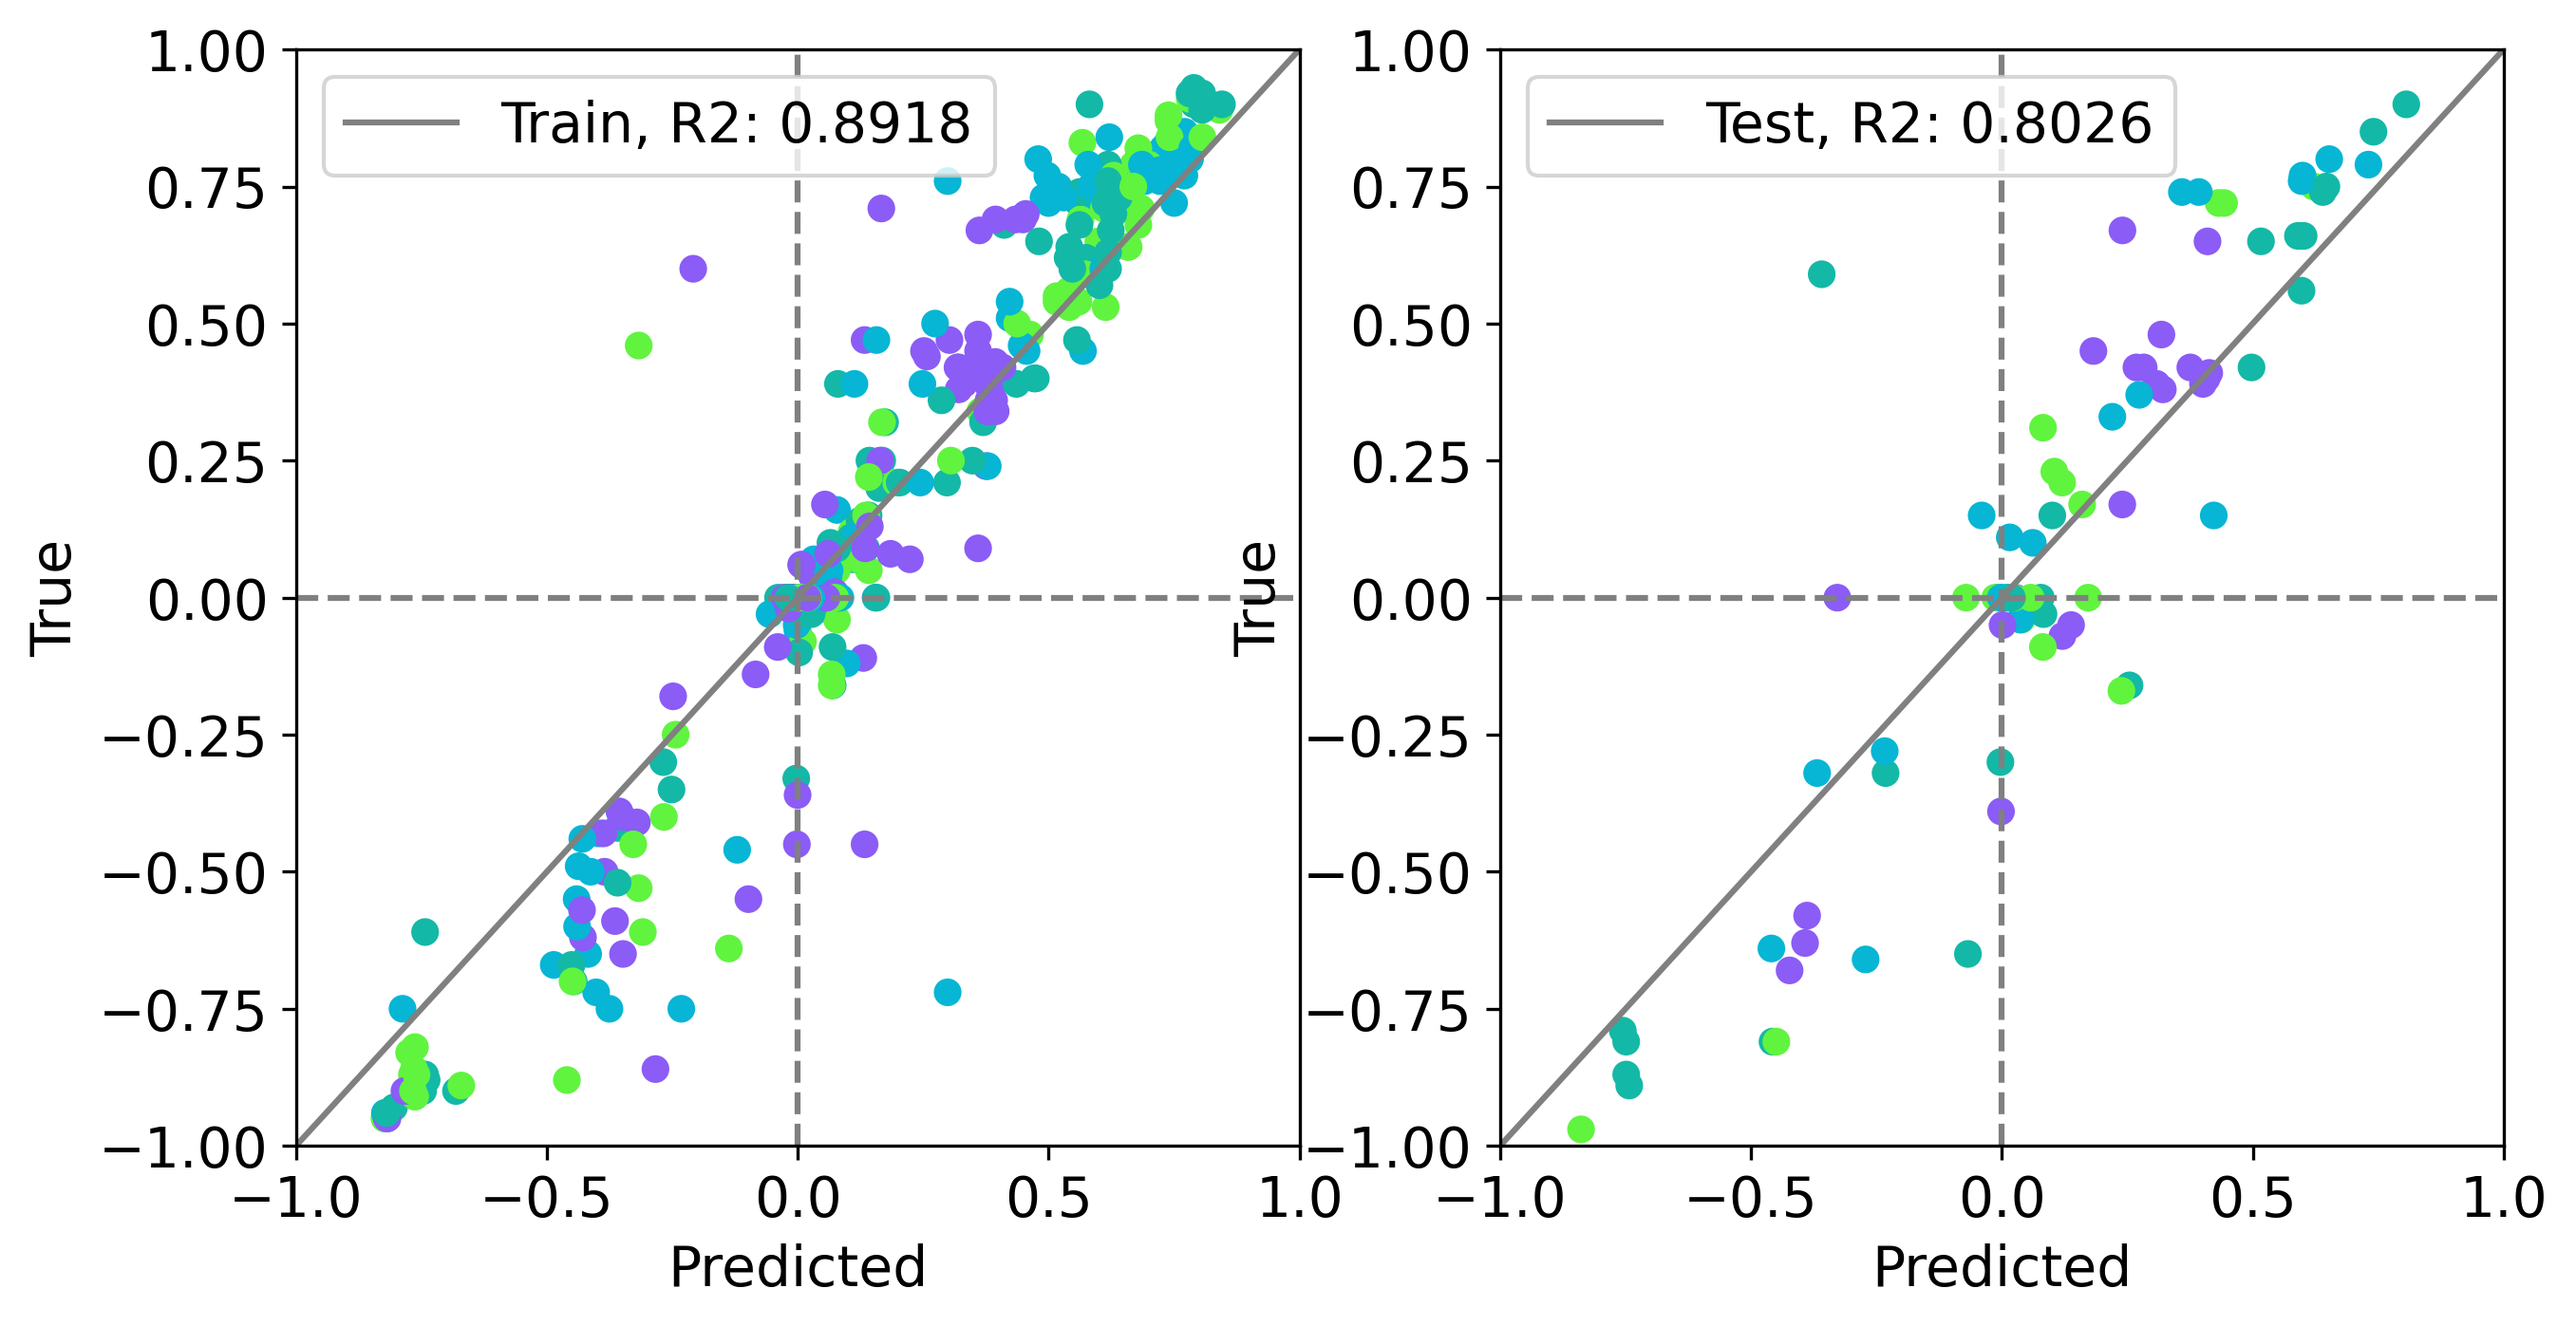

In [15]:
draw_pred_result(y_true_s = (y_train, y_test), y_pred_s = (train_pred, test_pred), r2_s = (r2_score(train_pred, y_train), r2_score(test_pred, y_test)), class_s = (class_train, class_test))

# rf模型

In [2]:

seed = 1
test_size = 0.2
prefix = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_416/4_gen_feature/rdkit_3"
data_x = np.load("{}_data_x.npy".format(prefix))
data_y = np.load("{}_data_y.npy".format(prefix))
with open("{}_x_label.pkl".format(prefix), "rb") as f:
    x_label = pickle.load(f)
with open("{}_data_class.pkl".format(prefix), "rb") as f:
    data_class = pickle.load(f)

# 超参之后的参数
rf_best_params = {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 140}
X_train, X_test, y_train, y_test,  class_train, class_test = train_test_split(
    data_x,        
    data_y,
    data_class,
    test_size=test_size,
    random_state=seed, 
)
model = build_model("rf", seed)
model.set_params(**rf_best_params)
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

from joblib import dump, load
# 需保存模型
dump(model, "rf_model_seed_1_split_0-2.pkl")



['rf_model_seed_1_split_0-2.pkl']